# AGResU-Net — BraTS 2019 (Project)


**Project Members:**

Ahmad alhajji 20190124

Sara Zoubi 20220131

Abdullah Hajjat 20230300


In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-04-19 11:45:38.116884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776599138.358221     343 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776599138.430929     343 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776599138.973283     343 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776599138.973319     343 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776599138.973321     343 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
import os
import gc
import math
import numpy as np
import nibabel as nib
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
DATASET_ROOT = "/kaggle/input/datasets/aryashah2k/brain-tumor-segmentation-brats-2019"
TRAIN_ROOT   = os.path.join(DATASET_ROOT, "MICCAI_BraTS_2019_Data_Training")
HGG_PATH     = os.path.join(TRAIN_ROOT, "HGG")
LGG_PATH     = os.path.join(TRAIN_ROOT, "LGG")

print("HGG exists:", os.path.exists(HGG_PATH))
print("LGG exists:", os.path.exists(LGG_PATH))
print("HGG patients:", len(os.listdir(HGG_PATH)))
print("LGG patients:", len(os.listdir(LGG_PATH)))

HGG exists: True
LGG exists: True
HGG patients: 259
LGG patients: 76


In [ ]:
def load_nifti(path):
    return nib.load(path).get_fdata().astype(np.float32)

def z_score(vol):
    mu, std = vol.mean(), vol.std()
    return (vol - mu) / (std + 1e-8)

def remap_labels(mask):
    # BraTS: 0=bg, 1=necrosis, 2=edema, 4=enhancing -> remap 4 to 3
    mask = mask.copy()
    mask[mask == 4] = 3
    return mask.astype(np.uint8)

def get_files(folder):
    paths = {"flair":None,"t1":None,"t1ce":None,"t2":None,"seg":None}
    for f in os.listdir(folder):
        fl = f.lower()
        fp = os.path.join(folder, f)
        if   fl.endswith("_flair.nii") or fl.endswith("_flair.nii.gz"): paths["flair"] = fp
        elif fl.endswith("_t1ce.nii")  or fl.endswith("_t1ce.nii.gz"):  paths["t1ce"]  = fp
        elif fl.endswith("_t1.nii")    or fl.endswith("_t1.nii.gz"):    paths["t1"]    = fp
        elif fl.endswith("_t2.nii")    or fl.endswith("_t2.nii.gz"):    paths["t2"]    = fp
        elif fl.endswith("_seg.nii")   or fl.endswith("_seg.nii.gz"):   paths["seg"]   = fp
    if any(v is None for v in paths.values()):
        raise ValueError(f"Missing file in {folder}: {[k for k,v in paths.items() if v is None]}")
    return paths

In [ ]:
def preload_all_slices(hgg_path, lgg_path, crop=128,
                       max_hgg=60, max_lgg=20):

    hgg_folders = sorted([os.path.join(hgg_path, f)
                          for f in os.listdir(hgg_path)
                          if os.path.isdir(os.path.join(hgg_path, f))])[:max_hgg]
    lgg_folders = sorted([os.path.join(lgg_path, f)
                          for f in os.listdir(lgg_path)
                          if os.path.isdir(os.path.join(lgg_path, f))])[:max_lgg]

    all_folders = hgg_folders + lgg_folders
    print(f"Loading {len(hgg_folders)} HGG + {len(lgg_folders)} LGG patients ...")

    X_list, Y_list = [], []
    pad = (240 - crop) // 2   # center crop offset (240->128)

    for idx, folder in enumerate(all_folders):
        try:
            p = get_files(folder)

            # load + normalize 4 modalities
            flair = z_score(load_nifti(p["flair"]))
            t1    = z_score(load_nifti(p["t1"]))
            t1ce  = z_score(load_nifti(p["t1ce"]))
            t2    = z_score(load_nifti(p["t2"]))
            seg   = remap_labels(load_nifti(p["seg"]))

            # stack -> (240, 240, 155, 4)
            vol = np.stack([flair, t1, t1ce, t2], axis=-1)

            # center crop spatial dims -> (128, 128, 155, 4)
            vol_c = vol[pad:pad+crop, pad:pad+crop, :, :]
            seg_c = seg[pad:pad+crop, pad:pad+crop, :]

            # keep only slices that have tumor
            for s in range(seg_c.shape[2]):
                if seg_c[:,:,s].sum() == 0:
                    continue
                img_sl  = vol_c[:, :, s, :].astype(np.float32)   # (128,128,4)
                mask_sl = seg_c[:, :, s]                           # (128,128)
                mask_oh = tf.keras.utils.to_categorical(mask_sl, 4).astype(np.float32)
                X_list.append(img_sl)
                Y_list.append(mask_oh)

            del flair, t1, t1ce, t2, seg, vol, vol_c, seg_c
            gc.collect()

            if (idx+1) % 10 == 0:
                print(f"  [{idx+1}/{len(all_folders)}] slices so far: {len(X_list)}")

        except Exception as e:
            print(f"  Skipped {os.path.basename(folder)}: {e}")

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    del X_list, Y_list
    gc.collect()

    print(f"\nDone! X shape: {X.shape}  ({X.nbytes/1e9:.2f} GB)")
    print(f"       Y shape: {Y.shape}  ({Y.nbytes/1e9:.2f} GB)")
    return X, Y


X_all, Y_all = preload_all_slices(HGG_PATH, LGG_PATH, max_hgg=60, max_lgg=20)

Loading 60 HGG + 20 LGG patients ...
  [10/80] slices so far: 737
  [20/80] slices so far: 1368
  [30/80] slices so far: 1998
  [40/80] slices so far: 2652
  [50/80] slices so far: 3334
  [60/80] slices so far: 3964
  [70/80] slices so far: 4452
  [80/80] slices so far: 5143

Done! X shape: (5143, 128, 128, 4)  (1.35 GB)
       Y shape: (5143, 128, 128, 4)  (1.35 GB)


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_all, Y_all,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)

del X_all, Y_all
gc.collect()

Train: (4114, 128, 128, 4)
Val  : (1029, 128, 128, 4)


0

In [ ]:
BATCH_SIZE = 16

def augment_fn(x, y):
    # random left-right flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_left_right(x)
        y = tf.image.flip_left_right(y)
    # random up-down flip
    if tf.random.uniform(()) > 0.5:
        x = tf.image.flip_up_down(x)
        y = tf.image.flip_up_down(y)
    return x, y

# training pipeline: shuffle -> augment -> batch -> prefetch
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, Y_train))
    .shuffle(buffer_size=2000, seed=42)
    .map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# validation pipeline: batch -> prefetch (no shuffle/augment needed)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, Y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Train batches:", len(X_train) // BATCH_SIZE)
print("Val   batches:", len(X_val)   // BATCH_SIZE)

I0000 00:00:1776599321.633306     343 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776599321.635971     343 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train batches: 257
Val   batches: 64


In [ ]:
def residual_block(x, filters):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, padding='same')(shortcut)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.PReLU(shared_axes=[1,2])(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.PReLU(shared_axes=[1,2])(x)
    return x


def attention_gate(x, g, inter_ch):
    # additive attention gate from Oktay et al. 2018
    theta_x = tf.keras.layers.Conv2D(inter_ch, 1, padding='same')(x)
    phi_g   = tf.keras.layers.Conv2D(inter_ch, 1, padding='same')(g)
    add     = tf.keras.layers.Add()([theta_x, phi_g])
    add     = tf.keras.layers.Activation('relu')(add)
    alpha   = tf.keras.layers.Conv2D(1, 1, padding='same')(add)
    alpha   = tf.keras.layers.Activation('sigmoid')(alpha)
    return tf.keras.layers.Multiply()([x, alpha])


def encoder_block(x, filters):
    x = residual_block(x, filters)
    p = tf.keras.layers.MaxPooling2D(2)(x)
    return x, p


def decoder_block(x, skip, filters):
    x    = tf.keras.layers.UpSampling2D(2, interpolation='bilinear')(x)
    skip = attention_gate(skip, x, inter_ch=max(filters//2, 1))
    x    = tf.keras.layers.Concatenate()([x, skip])
    x    = residual_block(x, filters)
    return x

In [ ]:
def build_agresunet(input_shape=(128, 128, 4), num_classes=4):
    inputs = tf.keras.layers.Input(shape=input_shape)

    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1,     64)
    s3, p3 = encoder_block(p2,     128)

    b = residual_block(p3, 256)

    d1 = decoder_block(b,  s3, 128)
    d2 = decoder_block(d1, s2, 64)
    d3 = decoder_block(d2, s1, 32)

    out = tf.keras.layers.Conv2D(num_classes, 1, activation='softmax')(d3)
    return tf.keras.Model(inputs, out, name="AGResU-Net")


model = build_agresunet()
model.summary()
print("\nTotal parameters:", model.count_params())

Model: "AGResU-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu (PReLU)     │ (None, 128, 128,  │         32 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ p_re_lu[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_1 (PReLU)   │ (None, 128, 128,  │         32 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ p_re_lu_1[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_2 (PReLU)   │ (None, 64, 64,    │         64 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ p_re_lu_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 2,095,255 (7.99 MB)

 Trainable params: 2,092,439 (7.98 MB)

 Non-trainable params: 2,816 (11.00 KB)


Total parameters: 2095255


In [ ]:
LAMBDA = 1.0   # weight for WCE term (paper Section II-C)

def generalized_dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    # sum over spatial dims -> (batch, classes)
    sum_true = tf.reduce_sum(y_true, axis=[1, 2])
    w = 1.0 / (tf.square(sum_true) + smooth)
    num   = w * tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    denom = w * tf.reduce_sum(y_true + y_pred,  axis=[1, 2])
    gdl = 1.0 - 2.0 * (tf.reduce_sum(num,   axis=-1) + smooth) / (tf.reduce_sum(denom, axis=-1) + smooth)
    return tf.reduce_mean(gdl)

def weighted_cross_entropy(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    # class weights from label frequency -> shape (num_classes,)
    freq = tf.reduce_sum(y_true, axis=[0, 1, 2]) + smooth
    w    = 1.0 / freq
    w    = w / tf.reduce_sum(w)
    # multiply weight along class axis (last dim), sum over classes, mean over rest
    per_pixel = tf.reduce_sum(y_true * tf.math.log(y_pred + smooth) * w, axis=-1)
    return -tf.reduce_mean(per_pixel)

def combined_loss(y_true, y_pred):
    return generalized_dice_loss(y_true, y_pred) + LAMBDA * weighted_cross_entropy(y_true, y_pred)

def mean_dice(y_true, y_pred, smooth=1e-6):
    y_true       = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    denom        = tf.reduce_sum(y_true + y_pred,  axis=[1, 2])
    return tf.reduce_mean((2.0 * intersection + smooth) / (denom + smooth))

In [ ]:
# SGD with lr=0.086, momentum=0.97 as in paper Section III-D
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.086, momentum=0.97, nesterov=True),
    loss=combined_loss,
    metrics=[mean_dice]
)
print("Compiled with SGD  lr=0.086  momentum=0.97")

Compiled with SGD  lr=0.086  momentum=0.97


In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/agresunet_best.keras",
        monitor="val_mean_dice", mode="max",
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_mean_dice", mode="max",
        patience=6, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_mean_dice", mode="max",
        factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.7550 - mean_dice: 0.5609
Epoch 1: val_mean_dice improved from -inf to 0.49572, saving model to /kaggle/working/agresunet_best.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 68s 195ms/step - loss: 0.7550 - mean_dice: 0.5609 - val_loss: 0.8298 - val_mean_dice: 0.4957 - learning_rate: 0.0860
Epoch 2/20
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.7355 - mean_dice: 0.5776
Epoch 2: val_mean_dice improved from 0.49572 to 0.57299, saving model to /kaggle/working/agresunet_best.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 36s 140ms/step - loss: 0.7354 - mean_dice: 0.5776 - val_loss: 0.7504 - val_mean_dice: 0.5730 - learning_rate: 0.0860
Epoch 3/20
257/258 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.7220 - mean_dice: 0.5899
Epoch 3: val_mean_dice did not improve from 0.57299
258/258 ━━━━━━━━━━━━━━━━━━━━ 35s 137ms/step - loss: 0.7220 - mean_dice: 0.5899 - val_loss: 0.8022 - val_mean_dice: 0.5133 - learning_rate: 0.0860
Epoch 4/20
257/258 ━━━━━━━

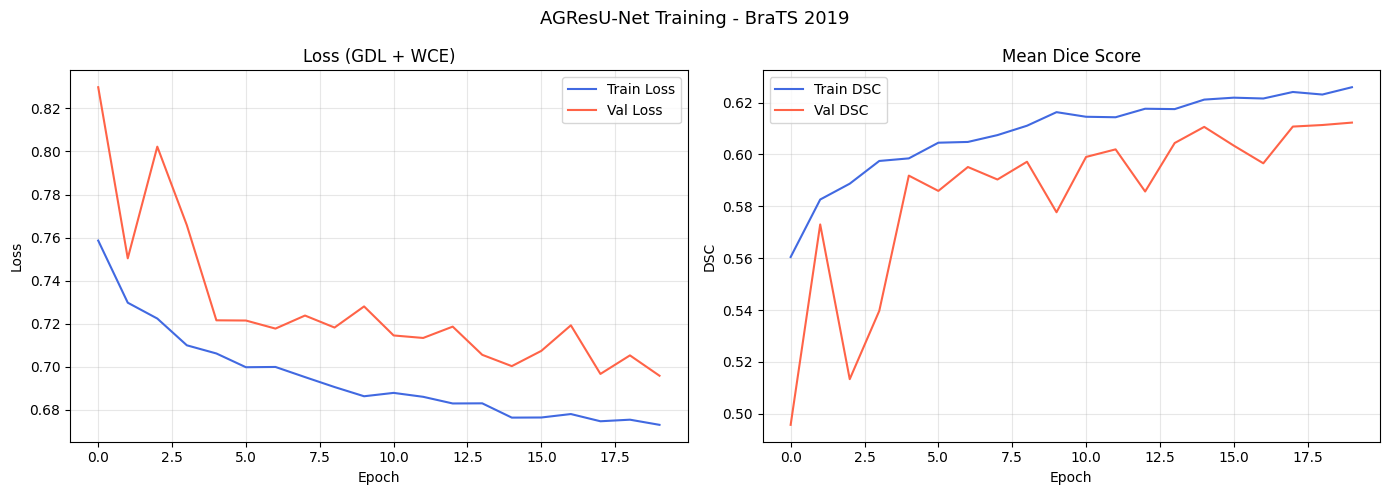

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train Loss', color='royalblue')
ax1.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
ax1.set_title('Loss (GDL + WCE)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mean_dice'],     label='Train DSC', color='royalblue')
ax2.plot(history.history['val_mean_dice'], label='Val DSC',   color='tomato')
ax2.set_title('Mean Dice Score')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('DSC')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("AGResU-Net Training - BraTS 2019", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

In [ ]:
def brats_dice_numpy(y_true_hard, y_pred_hard, smooth=1e-6):
    def dice(a, b):
        return (2*(a*b).sum() + smooth) / (a.sum() + b.sum() + smooth)

    wt_t = ((y_true_hard>=1)).astype(float);  wt_p = ((y_pred_hard>=1)).astype(float)
    tc_t = ((y_true_hard==1)|(y_true_hard==3)).astype(float)
    tc_p = ((y_pred_hard==1)|(y_pred_hard==3)).astype(float)
    et_t = (y_true_hard==3).astype(float);    et_p = (y_pred_hard==3).astype(float)

    return dice(wt_t, wt_p), dice(tc_t, tc_p), dice(et_t, et_p)


print("Evaluating BraTS regions on validation set ...")
wt, tc, et = [], [], []

for xb, yb in val_ds:
    preds     = model.predict(xb, verbose=0)
    true_hard = np.argmax(yb.numpy(),    axis=-1)
    pred_hard = np.argmax(preds,         axis=-1)
    wt_s, tc_s, et_s = brats_dice_numpy(true_hard, pred_hard)
    wt.append(wt_s); tc.append(tc_s); et.append(et_s)

print()
print("=" * 42)
print("  BraTS Dice Similarity Coefficient")
print("=" * 42)
print(f"  Whole Tumor  (WT) : {np.mean(wt):.4f}")
print(f"  Tumor Core   (TC) : {np.mean(tc):.4f}")
print(f"  Enhancing    (ET) : {np.mean(et):.4f}")
print("=" * 42)

Evaluating BraTS regions on validation set ...

  BraTS Dice Similarity Coefficient
  Whole Tumor  (WT) : 0.8940
  Tumor Core   (TC) : 0.8498
  Enhancing    (ET) : 0.8205


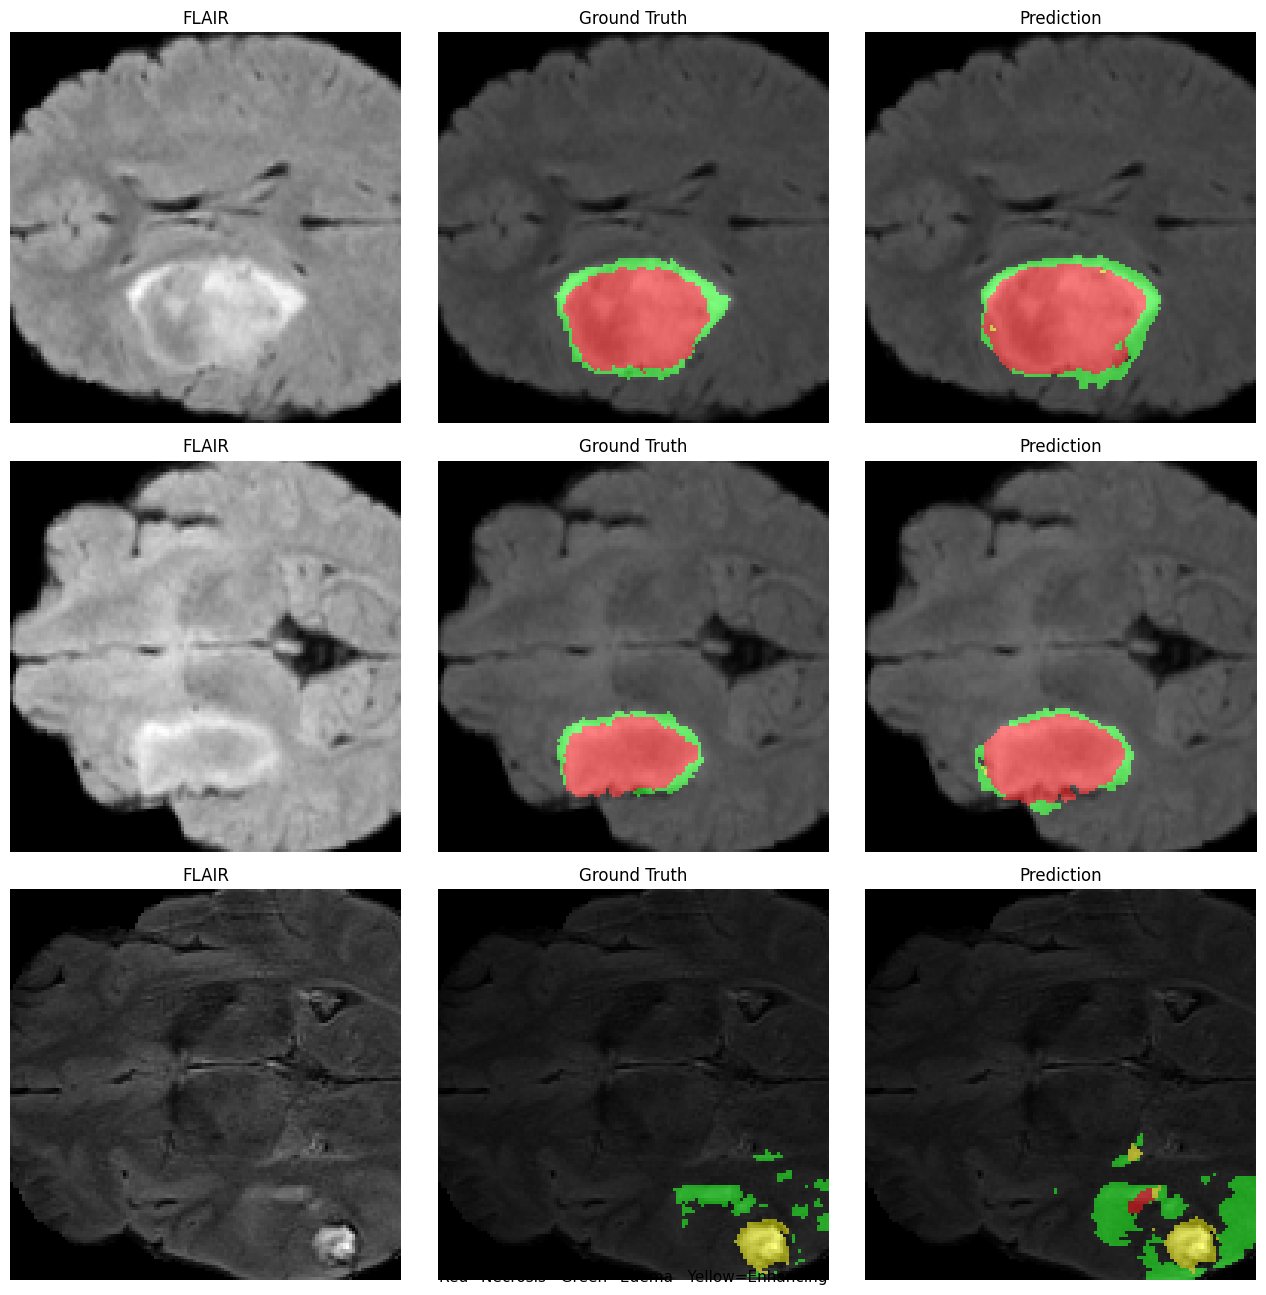

In [ ]:
xb, yb = next(iter(val_ds))
preds  = model.predict(xb[:3], verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
for row in range(3):
    flair    = xb[row].numpy()[:, :, 0]
    true_m   = np.argmax(yb[row].numpy(), axis=-1)
    pred_m   = np.argmax(preds[row],      axis=-1)

    def to_rgb(m):
        rgb = np.zeros((*m.shape, 3), dtype=np.uint8)
        rgb[m==1] = [255,  0,  0]
        rgb[m==2] = [  0,255,  0]
        rgb[m==3] = [255,255,  0]
        return rgb

    for col, (img, title) in enumerate([
        (flair,         "FLAIR"),
        (to_rgb(true_m),"Ground Truth"),
        (to_rgb(pred_m),"Prediction"),
    ]):
        if col == 0:
            axes[row, col].imshow(img, cmap='gray')
        else:
            axes[row, col].imshow(flair, cmap='gray')
            axes[row, col].imshow(img, alpha=0.5)
        axes[row, col].set_title(title)
        axes[row, col].axis('off')

fig.text(0.5, 0.01,
         "Red=Necrosis   Green=Edema   Yellow=Enhancing",
         ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/predictions.png", dpi=150)
plt.show()

In [ ]:
model.save("/kaggle/working/agresunet_final.keras")
print("Saved to /kaggle/working/agresunet_final.keras")

Saved to /kaggle/working/agresunet_final.keras
